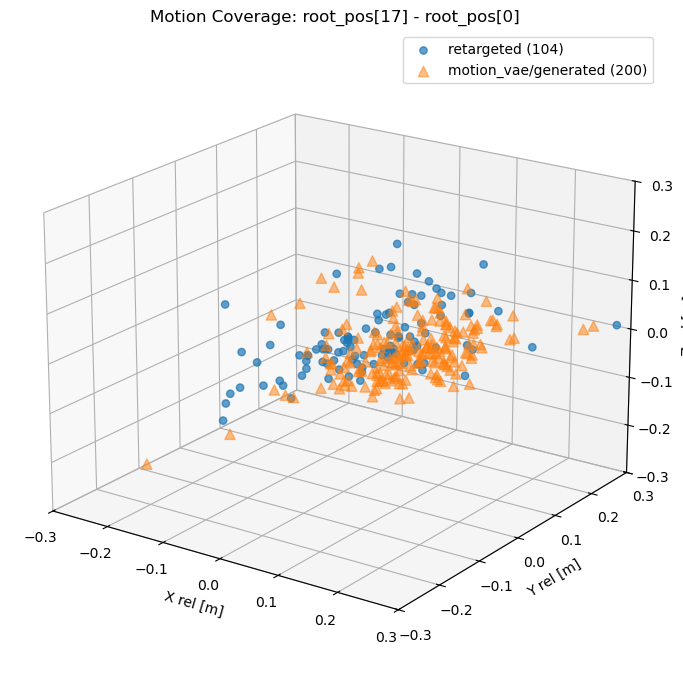

In [10]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np


HIT_FRAME = 17

RETARGETED_ROOTS = [
    Path("retargeted/trial_05"),
    Path("retargeted/trial_06"),
]
GENERATED_ROOT = Path("motion_vae/generated")


def load_root_rel(path, hit_frame=HIT_FRAME):
    with path.open("rb") as f:
        data = pickle.load(f)

    root_pos = np.asarray(data["root_pos"])
    hit_frame = min(hit_frame, len(root_pos) - 1)

    p_hit = root_pos[hit_frame]
    p_base = root_pos[0]
    return p_hit - p_base


retargeted_files = []
for root in RETARGETED_ROOTS:
    retargeted_files.extend(sorted(root.glob("*.pkl")))

generated_files = sorted(GENERATED_ROOT.glob("*.pkl"))

retargeted_pts = np.array([load_root_rel(path) for path in retargeted_files])
generated_pts = np.array([load_root_rel(path) for path in generated_files])

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

if len(retargeted_pts):
    ax.scatter(
        retargeted_pts[:, 0],
        retargeted_pts[:, 1],
        retargeted_pts[:, 2],
        s=28,
        alpha=0.7,
        label=f"retargeted ({len(retargeted_pts)})",
    )

if len(generated_pts):
    ax.scatter(
        generated_pts[:, 0],
        generated_pts[:, 1],
        generated_pts[:, 2],
        s=55,
        alpha=0.5,
        marker="^",
        label=f"motion_vae/generated ({len(generated_pts)})",
    )

ax.set_title("Motion Coverage: root_pos[17] - root_pos[0]")
ax.set_xlabel("X rel [m]")
ax.set_ylabel("Y rel [m]")
ax.set_zlabel("Z rel [m]")
ax.set_xlim(-0.3, 0.3)
ax.set_ylim(-0.3, 0.3)
ax.set_zlim(-0.3, 0.3)
ax.legend()
ax.grid(True)
ax.view_init(elev=20, azim=-55)
plt.tight_layout()
plt.show()

In [1]:
import ezc3d
import numpy as np

c3d = ezc3d.c3d("footwork_03.c3d")

print(c3d.keys())
print(c3d["parameters"].keys())
print(c3d["data"].keys())
points = c3d["data"]["points"]
print(points.shape)
markers_xyz = points[:3]                       # (3, M, T)
markers_xyz = np.transpose(markers_xyz, (2, 1, 0))  # (T, M, 3)

print(markers_xyz.shape)

OSError: The c3d file could not be opened, please verify the path: iostream error

In [2]:
marker_labels = c3d["parameters"]["POINT"]["LABELS"]["value"]
frame_rate = c3d["parameters"]["POINT"]["RATE"]["value"][0]

print("Frame rate:", frame_rate)
print("Markers:", marker_labels)

NameError: name 'c3d' is not defined

In [3]:
import plotly.graph_objects as go

def visualize_frame(markers_xyz, marker_labels=None, frame_idx=0):
    pts = markers_xyz[frame_idx]  # (M, 3)

    fig = go.Figure(data=[
        go.Scatter3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            mode="markers+text" if marker_labels is not None else "markers",
            text=marker_labels if marker_labels is not None else None,
            marker=dict(size=4),
        )
    ])

    fig.update_layout(
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        title=f"Frame {frame_idx}",
    )
    fig.show()

visualize_frame(markers_xyz, marker_labels, frame_idx=0)

NameError: name 'markers_xyz' is not defined